In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astroquery.mast import Observations

---
## COS test

STIS done. Now COS. First lets just find a SN that actually has some COS UV data and pull MAST's default x1d to look at it. COS is photon-counting (calcos), so apparently custom extraction later is a different beast than stistools.x1d (edit XTRACTAB boxes + rerun calcos).


In [13]:
# find SNe with COS spectra. target_name is proposer-typed but a lot of SNe do get logged as 'SN*'
cos = Observations.query_criteria(obs_collection="HST", instrument_name="COS*", target_name="SN*")
print(f"{len(cos)} COS obs under SN* names")

# collapse to unique targets so we can pick one
from astropy.table import unique
u = unique(cos, keys="target_name")
u["target_name", "filters", "t_exptime", "proposal_id"]


148 COS obs under SN* names


target_name,filters,t_exptime,proposal_id
str19,str41,float64,str5
SN 1895B,G130M;G160M,8166.656000000001,MULTI
SN 1968L,G130M;G160M,3084.2239999999997,MULTI
SN 1983I,E140M;G130M;G160M;G750M,20644.528,MULTI
SN 1987A,G130M;G160M;G230L;G430L;G430M;G750L;G750M,54153.52799999999,MULTI
SN 1993J,G140L;G230L,29968.127999999997,12531
SN 2009ip,G130M;G140L;G160M;G230LB;G430L;G750L,10719.864,MULTI
SN 2010al,G140L;G230LB;G430L,8400.0,11654
SN 2010jl,G130M;G140L;G160M;G230L;G430L,20549.688,MULTI
SN 2014C,G140L;G230LB;G430L,10617.648000000001,14202


In [ ]:
# go with SN2023ixf - type II in M101. dedicated COS G230L visit (prop 17497)
ixf = Observations.query_criteria(objectname="SN2023ixf", obs_collection="HST", instrument_name="COS*", radius="0.01 deg") # before it was 3 arcmin, made smaller to 0.01-0.02 deg ~ 0.6 arcmin
print(f"{len(ixf)} COS obs near SN2023ixf")
ixf["obs_id", "instrument_name", "filters", "t_exptime", "target_name", "proposal_id"]


10 COS obs near SN2023ixf


obs_id,instrument_name,filters,t_exptime,target_name,proposal_id
str37,str8,str23,float64,str13,str5
ldjia3010,COS/FUV,G140L,1972.0,+254.6-107.2,15126
lf8803050,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
hst_hsla_sn2023ixf--3586,COS-STIS,G140L;G230L;G430L;G750L,12697.126625,SN 2023ixf,MULTI
lf8803d3q,COS/NUV,MIRRORA,5.0,SN2023IXF-COS,17497
lf8803030,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
lf8803040,COS/NUV,G230L,629.184,SN2023IXF-COS,17497
lf8803010,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
lf8803020,COS/NUV,G230L,337.0,SN2023IXF-COS,17497
hst_hasp_17497_cos_sn2023ixf-cos_lf88,COS,G230L,6704.928,SN2023IXF-COS,17497


In [15]:
# grab one COS/NUV G230L exposure and pull its default x1dsum (the summed 1d product)
one = ixf[ixf["obs_id"] == "lf8803010"]
cprod = Observations.get_product_list(one)
cx1d = Observations.filter_products(cprod, productSubGroupDescription=["X1DSUM", "X1D"], extension="fits")
cman = Observations.download_products(cx1d, download_dir=".../data/2023ixf")
cman["Local Path", "Status"]


Local Path,Status
str63,str8
.../data/2023ixf\mastDownload\HST\lf8803010\lf8803010_x1dsum.fits,COMPLETE
.../data/2023ixf\mastDownload\HST\lf8803d5q\lf8803d5q_x1d.fits,COMPLETE


3 stripes: ['NUVA', 'NUVB', 'NUVC']


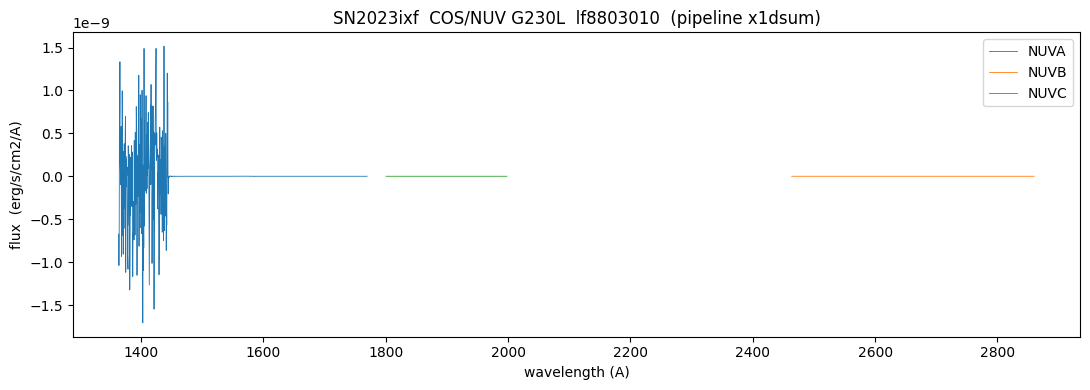

In [16]:
# COS NUV lands on 3 stripes (NUVA/B/C) so the x1dsum has 3 rows. COS masks on DQ_WGT (0 = thrown out)
cosx1d = ".../data/2023ixf/mastDownload/HST/lf8803010/lf8803010_x1dsum.fits"
ct = Table.read(cosx1d, hdu=1)
print(len(ct), "stripes:", list(ct['SEGMENT']))

plt.figure(figsize=(11, 4))
for r in ct:
    w, f, dqw = r['WAVELENGTH'], r['FLUX'], r['DQ_WGT']
    m = dqw > 0
    plt.plot(w[m], f[m], lw=0.6, label=r['SEGMENT'])
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  lf8803010  (pipeline x1dsum)'); plt.legend()
plt.tight_layout(); plt.show()


INFO: Found cached file .../data/2023ixf\mastDownload\HST\lf8803050\lf8803050_asn.fits with expected size 11520. [astroquery.query]
INFO: Found cached file .../data/2023ixf\mastDownload\HST\lf8803050\lf8803050_jif.fits with expected size 34560. [astroquery.query]
INFO: Found cached file .../data/2023ixf\mastDownload\HST\lf8803050\lf8803050_jit.fits with expected size 77760. [astroquery.query]
INFO: Found cached file .../data/2023ixf\mastDownload\HST\lf8803050\lf8803050_trl.fits with expected size 8640. [astroquery.query]
INFO: Found cached file .../data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum3.fits with expected size 259200. [astroquery.query]
INFO: Found cached file .../data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum_prev.fits with expected size 115200. [astroquery.query]
INFO: Found cached file .../data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum3_prev.fits with expected size 115200. [astroquery.query]
INFO: Found cached file .../data/2023ixf\mastDownload

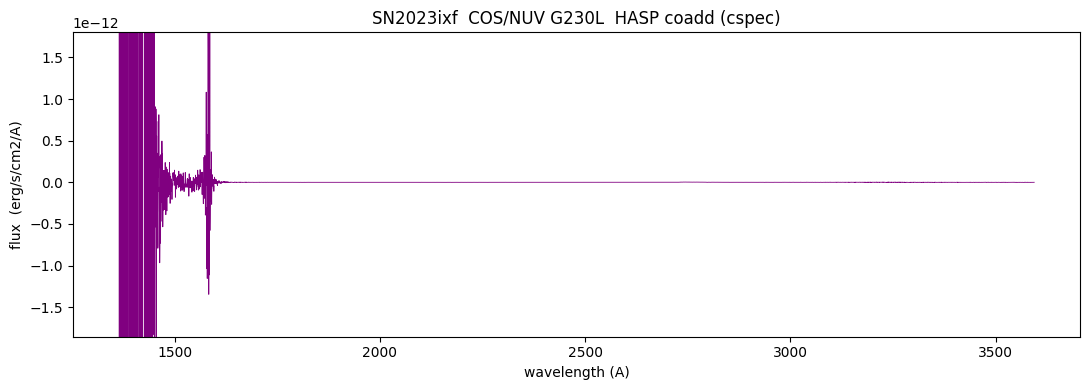

In [ ]:
# i guess one exposure is faint. lets try grabbing the HASP coadd of the whole G230L visit for a clean look (details in data_access)
hasp = ixf[ixf["obs_id"] == "hst_hasp_17497_cos_sn2023ixf-cos_lf88"]
hprod = Observations.get_product_list(hasp)
hman = Observations.download_products(hprod, download_dir=".../data/2023ixf", extension="fits")
cspec_path = [p for p in hman["Local Path"] if p.endswith("cspec.fits")][0]

hc = Table.read(cspec_path, hdu=1)
w, f, eff = hc['WAVELENGTH'][0], hc['FLUX'][0], hc['EFF_EXPTIME'][0]
# only where there's real coadded coverage. the blue edge has huge-error spikes that wreck the y-scale, so clip those
m = (eff > 0) & np.isfinite(f)
lo, hi = np.nanpercentile(f[m], [2, 98])

plt.figure(figsize=(11, 4))
plt.plot(w[m], f[m], lw=0.6, color='purple')
plt.ylim(lo - abs(lo), hi * 1.3)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  HASP coadd (cspec)')
plt.tight_layout(); plt.show() # uh oh that pulled the full product set (all the rawtag/corrtag/flt too, not just cspec)
# NOTE: ^ can use these as calcos inputs later


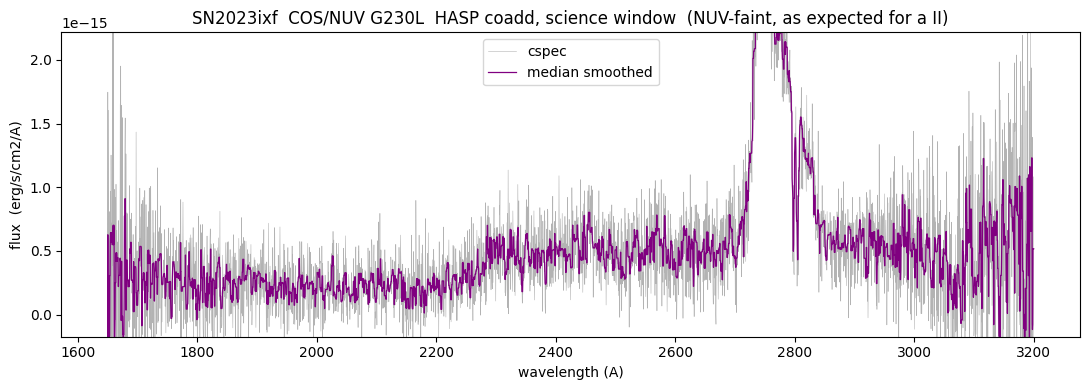

In [20]:
# zoom into the actual G230L science window (the blue end <1650 is 2nd-order/airglow junk).
# uses the in-memory cspec from the cell above so no re-download.
from scipy.ndimage import median_filter
sci = m & (w > 1650) & (w < 3200)
wsci = np.asarray(w[sci], dtype=float)
fsci = np.asarray(f[sci], dtype=float)   # fits is big-endian, scipy wants native
fs = median_filter(fsci, size=7)         # light smooth just to see the continuum shape
lo, hi = np.nanpercentile(fsci, [5, 95])

plt.figure(figsize=(11, 4))
plt.plot(wsci, fsci, lw=0.4, color='0.7', label='cspec')
plt.plot(wsci, fs, lw=0.9, color='purple', label='median smoothed')
plt.ylim(lo - abs(lo), hi * 1.4)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  HASP coadd, science window  (NUV-faint, as expected for a II)')
plt.legend(); plt.tight_layout(); plt.show()


---
## COS custom extraction (calcos + XTRACTAB)

calcos is the COS pipeline (pure python, separate from hstcal). it runs in the same WSL surf_uv env. the COS analog of the STIS trace+aperture is the XTRACTAB: it holds the extraction box (B_SPEC center, HEIGHT) + bg boxes per stripe/grating/cenwave. NUV uses BOXCAR extraction so editing the boxes just works (FUV defaults to TWOZONE, would need XTRCTALG=BOXCAR).

workflow (all in WSL): sync COS refs -> `reduce_cos.py` runs calcos default -> `reduce_cos_custom.py` copies the XTRACTAB, narrows the source box HEIGHT (57 -> 15), points a copy of the corrtag at it, re-runs calcos. here we compare.


NUVA: B_SPEC=174.1  peak(YFULL)=174  offset=-0.1 px
NUVB: B_SPEC=277.8  peak(YFULL)=275  offset=-2.8 px
NUVC: B_SPEC=418.3  peak(YFULL)=417  offset=-1.3 px


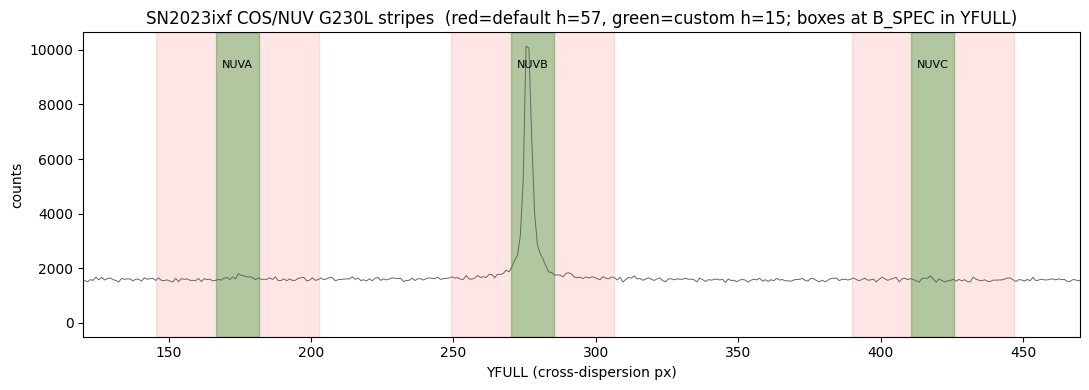

In [3]:
# collapse the corrtag counts onto the cross-dispersion axis to see the 3 NUV stripes + our boxes.
# use YFULL, not YCORR: B_SPEC lives in the fully-corrected YFULL frame. over YCORR the boxes looked
# ~5-7px off (that was the "NUVB on the left edge" worry); in YFULL they sit on the stripes (<3px off).
ct = "../data/2023ixf/mastDownload/HST/lf8803d5q/lf8803d5q_corrtag.fits"
ev = Table.read(ct, hdu=1)
yprof, yedges = np.histogram(ev['YFULL'], bins=np.arange(0, 1025))
yc = 0.5 * (yedges[:-1] + yedges[1:])

to = Table.read("../crds_cache/references/hst/cos/69f1919fl_1dx.fits", hdu=1)
te = Table.read("../data/2023ixf/cos_work/edit_1dx.fits", hdu=1)
sel = (to['OPT_ELEM'] == 'G230L') & (to['CENWAVE'] == 2635) & (to['APERTURE'] == 'PSA')
rows, erows = to[sel], te[sel]

plt.figure(figsize=(11, 4))
plt.plot(yc, yprof, lw=0.7, color='0.4')
for r, er in zip(rows, erows):
    b, hd, hcst = r['B_SPEC'], r['HEIGHT'], er['HEIGHT']
    lo, hi = int(b - hd/2), int(b + hd/2)
    pk = lo + int(np.argmax(yprof[lo:hi]))                            # measured stripe peak (YFULL)
    plt.axvspan(b - hd/2, b + hd/2, color='red', alpha=0.10)         # default box
    plt.axvspan(b - hcst/2, b + hcst/2, color='green', alpha=0.30)   # our narrow custom box
    plt.text(b, yprof.max()*0.92, r['SEGMENT'], ha='center', fontsize=8)
    print(f"{r['SEGMENT']}: B_SPEC={b:.1f}  peak(YFULL)={pk}  offset={pk-b:+.1f} px")
plt.xlim(120, 470); plt.xlabel('YFULL (cross-dispersion px)'); plt.ylabel('counts')
plt.title(f"SN2023ixf COS/NUV G230L stripes  (red=default h={rows['HEIGHT'][0]:.0f}, green=custom h={erows['HEIGHT'][0]:.0f}; boxes at B_SPEC in YFULL)")
plt.tight_layout(); plt.show()

NUVA: flux std  default=2.65e-10  custom=1.28e-10
NUVB: flux std  default=8.11e-16  custom=7.03e-16
NUVC: flux std  default=4.84e-15  custom=2.49e-15


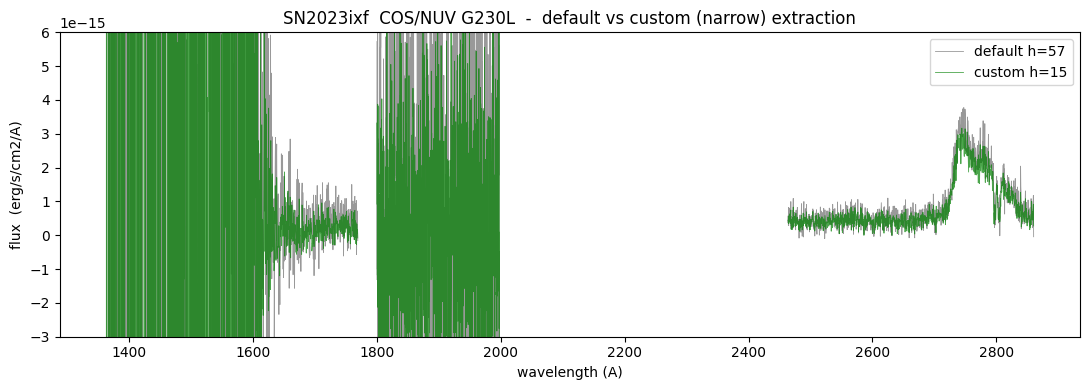

In [ ]:
# default vs custom (narrow box) extracted spectra, all 3 NUV stripes
xd = Table.read(".../data/2023ixf/cos_out_default/lf8803d5q_x1d.fits", hdu=1)
xc = Table.read(".../data/2023ixf/cos_out_custom/lf8803d5q_x1d.fits", hdu=1)

plt.figure(figsize=(11, 4))
for i in range(len(xd)):
    seg = xd['SEGMENT'][i]
    wd, fd, gd = xd['WAVELENGTH'][i], xd['FLUX'][i], xd['DQ_WGT'][i] > 0
    wc, fc, gc = xc['WAVELENGTH'][i], xc['FLUX'][i], xc['DQ_WGT'][i] > 0
    plt.plot(wd[gd], fd[gd], lw=0.6, color='0.6', label='default h=57' if i == 0 else None)
    plt.plot(wc[gc], fc[gc], lw=0.6, color='green', alpha=0.7, label='custom h=15' if i == 0 else None)
    # narrower box should let in less background -> lower flux scatter
    print(f"{seg}: flux std  default={np.nanstd(fd[gd]):.2e}  custom={np.nanstd(fc[gc]):.2e}")
plt.ylim(-3e-15, 6e-15)   # the SN is NUV-faint, clip the contaminated-stripe noise spikes
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)'); plt.legend()
plt.title('SN2023ixf  COS/NUV G230L  -  default vs custom (narrow) extraction')
plt.tight_layout(); plt.show()


### NUV box-height sweep (interactive, like the STIS extrsize sweep)

ran calcos for a range of source-box heights (5,9,15,25,41,57) via `reduce_cos_sweep.py`. narrow box = less background but eventually clips the stripe; wide box = more sky/noise. find the sweet spot on the science stripe.


per-stripe SNR (default): {'NUVA': np.float64(0.166), 'NUVB': np.float64(2.501), 'NUVC': np.float64(0.017)}


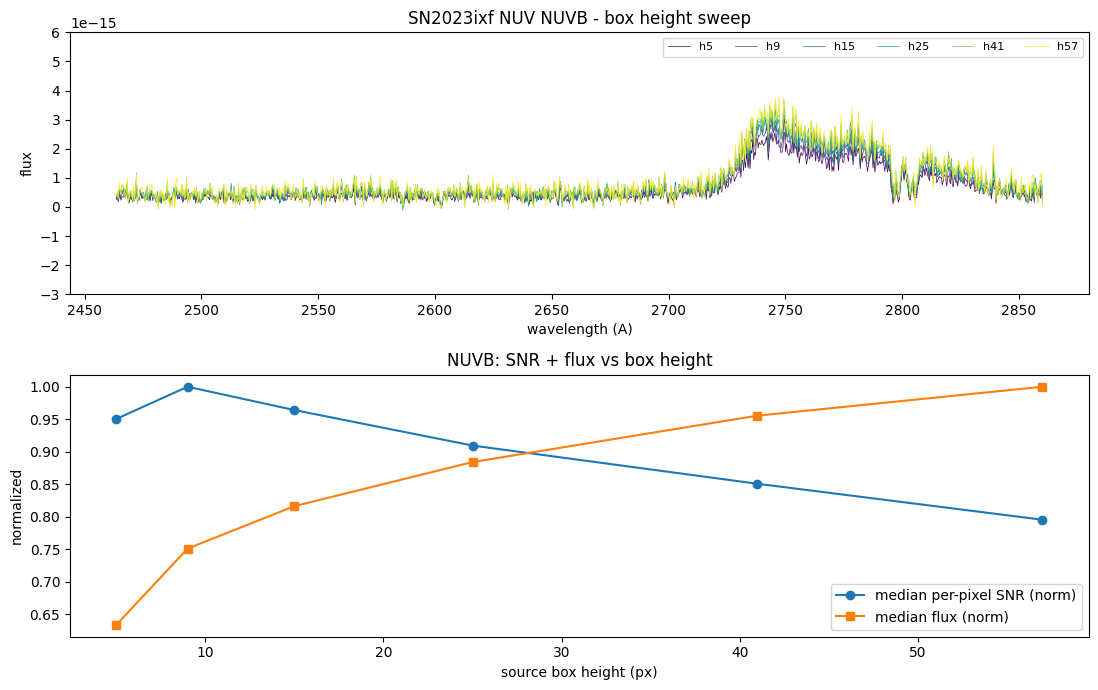

SNR by height: {5: np.float64(2.99), 9: np.float64(3.14), 15: np.float64(3.03), 25: np.float64(2.86), 41: np.float64(2.67), 57: np.float64(2.5)}


In [6]:
# NUV height sweep: overlay the science-stripe spectrum + SNR vs height
heights = [5, 9, 15, 25, 41, 57]
swp = ".../data/2023ixf/cos_sweep"

# pick the science stripe = segment with the best per-pixel SNR (flux/error), robust to NUVA's noise spikes
ref = Table.read(f"{swp}/h57/out/lf8803d5q_x1d.fits", hdu=1)
def seg_snr(t, i):
    g = t['DQ_WGT'][i] > 0
    f = np.asarray(t['FLUX'][i][g], float); e = np.asarray(t['ERROR'][i][g], float)
    return np.nanmedian(f / np.where(e > 0, e, np.nan))
seg_snrs = {ref['SEGMENT'][i]: round(seg_snr(ref, i), 3) for i in range(len(ref))}
print("per-stripe SNR (default):", seg_snrs)
sci = int(np.nanargmax([seg_snr(ref, i) for i in range(len(ref))])); sciseg = ref['SEGMENT'][sci]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))
cols = plt.cm.viridis(np.linspace(0, 1, len(heights)))
snr, flux = [], []
for h, c in zip(heights, cols):
    t = Table.read(f"{swp}/h{h}/out/lf8803d5q_x1d.fits", hdu=1)
    w, f, e, g = t['WAVELENGTH'][sci], t['FLUX'][sci], t['ERROR'][sci], t['DQ_WGT'][sci] > 0
    ax1.plot(w[g], f[g], lw=0.5, color=c, label=f'h{h}')
    pix_snr = np.asarray(f[g], float) / np.asarray(e[g], float)
    snr.append(np.nanmedian(pix_snr)); flux.append(np.nanmedian(np.asarray(f[g], float)))
ax1.set_ylim(-3e-15, 6e-15); ax1.legend(ncol=6, fontsize=8)
ax1.set_xlabel('wavelength (A)'); ax1.set_ylabel('flux'); ax1.set_title(f'SN2023ixf NUV {sciseg} - box height sweep')

ax2.plot(heights, np.array(snr) / max(snr), 'o-', label='median per-pixel SNR (norm)')
ax2.plot(heights, np.array(flux) / max(flux), 's-', label='median flux (norm)')
ax2.set_xlabel('source box height (px)'); ax2.set_ylabel('normalized'); ax2.legend()
ax2.set_title(f'{sciseg}: SNR + flux vs box height')
plt.tight_layout(); plt.show()
print("SNR by height:", {h: round(s, 2) for h, s in zip(heights, snr)})


---
## COS FUV custom extraction (SN2010jl G130M)

2023ixf has no direct COS/FUV, so we use SN2010jl (bright Type IIn, real FUV). FUV has two detector segments FUVA/FUVB. This mode already defaults to BOXCAR so the box edits apply directly (TWOZONE modes would need XTRCTALG=BOXCAR). Same height sweep as NUV, via `reduce_cos_fuv_sweep.py`.


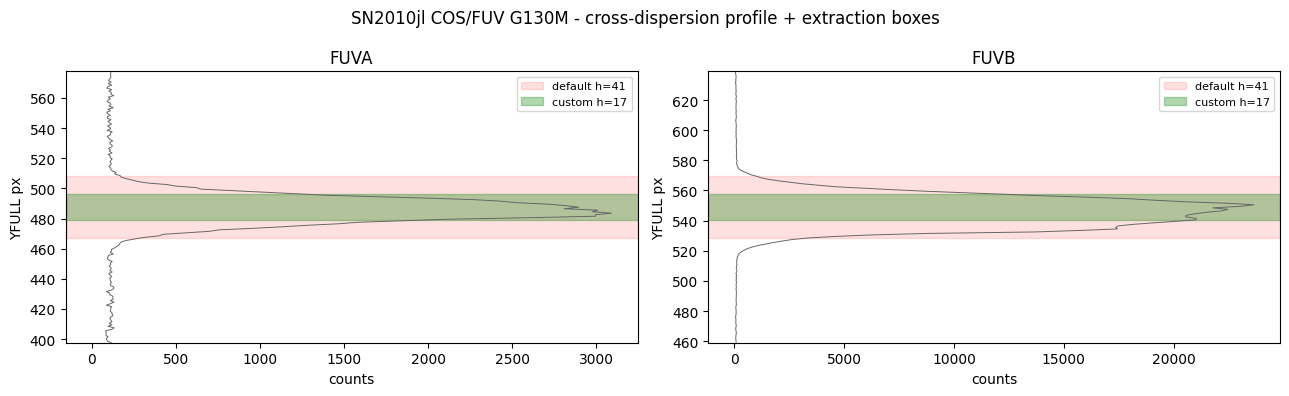

In [8]:
# FUV: collapse each segment's counts onto cross-dispersion Y, mark default vs custom boxes
# use the calcos-made corrtag (YFULL = geo-corrected frame the boxes live in), not the raw RAWY
ca = ".../data/2010jl/fuv_out_default/lboo22xrq_corrtag_a.fits"
cb = ca.replace('_corrtag_a', '_corrtag_b')
tf = Table.read(".../crds_cache/references/hst/cos/97h1816tl_1dx.fits", hdu=1)
selF = (tf['OPT_ELEM'] == 'G130M') & (tf['CENWAVE'] == 1291) & (tf['APERTURE'] == 'PSA')
boxes = {r['SEGMENT']: (r['B_SPEC'], r['HEIGHT']) for r in tf[selF]}

fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 4))
for ax, rt, seg in [(axa, ca, 'FUVA'), (axb, cb, 'FUVB')]:
    ev = Table.read(rt, hdu=1)
    yprof, yed = np.histogram(ev['YFULL'], bins=np.arange(0, 1025))
    ycc = 0.5 * (yed[:-1] + yed[1:])
    ax.plot(yprof, ycc, lw=0.7, color='0.4')
    b, hd = boxes[seg]
    ax.axhspan(b - hd/2, b + hd/2, color='red', alpha=0.12, label=f'default h={hd}')
    ax.axhspan(b - 17/2, b + 17/2, color='green', alpha=0.3, label='custom h=17')
    ax.set_title(seg); ax.set_xlabel('counts'); ax.set_ylabel('YFULL px')
    ax.set_ylim(b - 90, b + 90); ax.legend(fontsize=8)
plt.suptitle('SN2010jl COS/FUV G130M - cross-dispersion profile + extraction boxes')
plt.tight_layout(); plt.show()


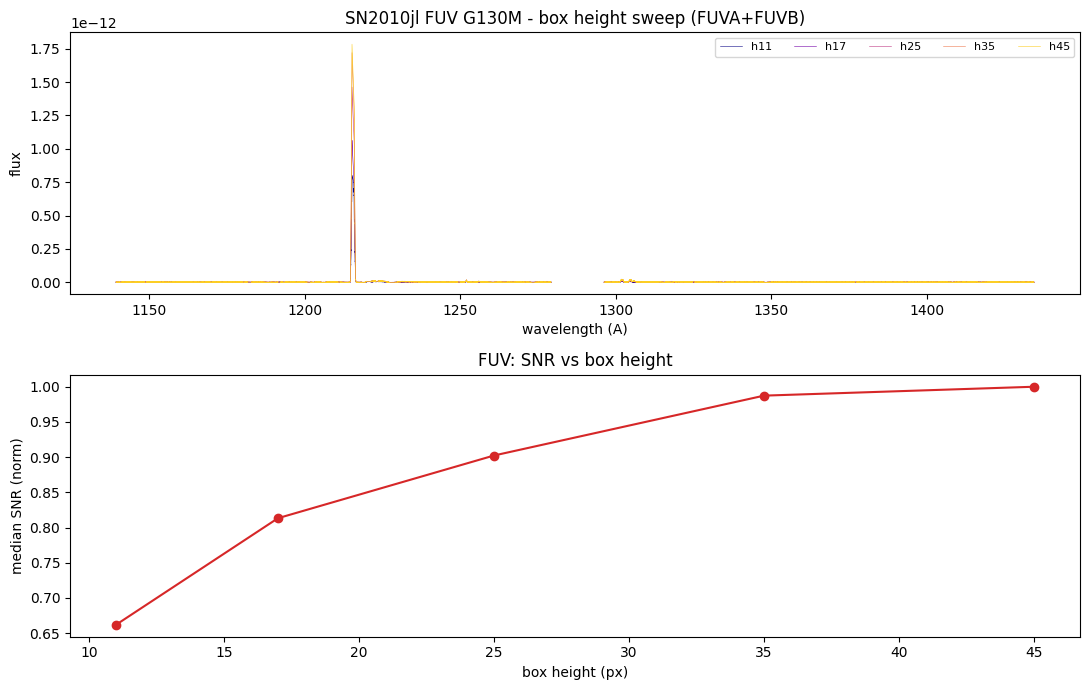

FUV SNR by height: {11: np.float64(0.73), 17: np.float64(0.9), 25: np.float64(1.0), 35: np.float64(1.09), 45: np.float64(1.1)}


In [9]:
# FUV height sweep: overlay both segments' spectra + SNR vs height
heights_f = [11, 17, 25, 35, 45]
fsw = ".../data/2010jl/fuv_sweep"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))
cols = plt.cm.plasma(np.linspace(0, 0.9, len(heights_f)))
snr_f = []
for h, c in zip(heights_f, cols):
    t = Table.read(f"{fsw}/h{h}/out/lboo22xrq_x1d.fits", hdu=1)
    seg_med = []
    for i in range(len(t)):
        w, f, e, g = t['WAVELENGTH'][i], t['FLUX'][i], t['ERROR'][i], t['DQ_WGT'][i] > 0
        ax1.plot(w[g], f[g], lw=0.4, color=c, label=f'h{h}' if i == 0 else None)
        pix = np.asarray(f[g], float) / np.asarray(np.where(e[g] > 0, e[g], np.nan), float)
        seg_med.append(np.nanmedian(pix))
    snr_f.append(np.nanmedian(seg_med))
ax1.legend(ncol=5, fontsize=8); ax1.set_xlabel('wavelength (A)'); ax1.set_ylabel('flux')
ax1.set_title('SN2010jl FUV G130M - box height sweep (FUVA+FUVB)')
ax2.plot(heights_f, np.array(snr_f) / max(snr_f), 'o-', color='C3')
ax2.set_xlabel('box height (px)'); ax2.set_ylabel('median SNR (norm)'); ax2.set_title('FUV: SNR vs box height')
plt.tight_layout(); plt.show()
print("FUV SNR by height:", {h: round(s, 2) for h, s in zip(heights_f, snr_f)})


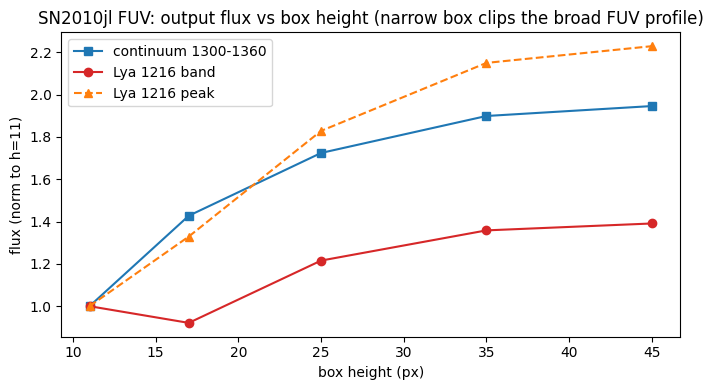

h45/h11  continuum=1.95  Lya band=1.39  Lya peak=2.23


In [5]:
# the FUV output flux depends a lot on box height: the cos fuv cross-dispersion profile is broad, so a
# narrow box clips real source flux. quantify it - continuum + Lya band + Lya peak vs box height.
heights_f = [11, 17, 25, 35, 45]
fsw = "../data/2010jl/fuv_sweep"

def band(t, lo, hi, reduce=np.nansum):
    vals = []
    for i in range(len(t)):
        w = np.asarray(t['WAVELENGTH'][i], float); f = np.asarray(t['FLUX'][i], float)
        g = (t['DQ_WGT'][i] > 0) & (w >= lo) & (w <= hi)
        if g.any():
            vals.append(f[g])
    return reduce(np.concatenate(vals)) if vals else np.nan

lya, lyapk, cont = [], [], []
for h in heights_f:
    t = Table.read(f"{fsw}/h{h}/out/lboo22xrq_x1d.fits", hdu=1)
    lya.append(band(t, 1213, 1219))                # Lya band (geocoronal 1215.7 obs)
    lyapk.append(band(t, 1213, 1219, np.nanmax))   # Lya peak
    cont.append(band(t, 1300, 1360))               # clean continuum on FUVA
lya, lyapk, cont = np.array(lya), np.array(lyapk), np.array(cont)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(heights_f, cont / cont[0], 's-', color='C0', label='continuum 1300-1360')
ax.plot(heights_f, lya / lya[0], 'o-', color='C3', label='Lya 1216 band')
ax.plot(heights_f, lyapk / lyapk[0], '^--', color='C1', label='Lya 1216 peak')
ax.set_xlabel('box height (px)'); ax.set_ylabel('flux (norm to h=11)')
ax.set_title('SN2010jl FUV: output flux vs box height (narrow box clips the broad FUV profile)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"h45/h11  continuum={cont[-1]/cont[0]:.2f}  Lya band={lya[-1]/lya[0]:.2f}  Lya peak={lyapk[-1]/lyapk[0]:.2f}")

In [7]:
# does h=45 capture meaningfully more flux than h=35 (both near plateau)?
# sweep ran h=[11,17,25,35,45]. h=41 (default) not in the sweep, but h=35 and h=45 bracket it.
heights_f = [11, 17, 25, 35, 45]
fsw = "../data/2010jl/fuv_sweep"

def med_flux(h, lo=1300, hi=1360):
    t = Table.read(f"{fsw}/h{h}/out/lboo22xrq_x1d.fits", hdu=1)
    vals = []
    for i in range(len(t)):
        w = np.asarray(t['WAVELENGTH'][i], float); f = np.asarray(t['FLUX'][i], float)
        g = (t['DQ_WGT'][i] > 0) & (w > lo) & (w < hi)
        if g.any(): vals.extend(f[g].tolist())
    return np.nanmedian(vals)

ref = med_flux(35)
print("continuum flux relative to h=35:")
for h in heights_f:
    print(f"  h={h:2d}: {med_flux(h)/ref:.3f}x")
print(f"\n -> h=45 captures {(med_flux(45)/ref-1)*100:.1f}% more continuum than h=35")

continuum flux relative to h=35:
  h=11: 0.509x
  h=17: 0.761x
  h=25: 1.004x
  h=35: 1.000x
  h=45: 0.994x

 -> h=45 captures -0.6% more continuum than h=35


---
## COS coadd (combine the NUV exposures + abut the stripes)

SN2023ixf has 6 NUV G230L exposures (different cenwaves/FP-POS), each landing 3 stripes (NUVA/B/C) at different wavelengths. our own coadd: resample every stripe of every exposure onto a common axis and median-combine. then check it against the HASP coadd (which does the same thing under the hood).


6 exposures -> 18 stripe spectra


        Use Spectrum instead. [_py_warnings]


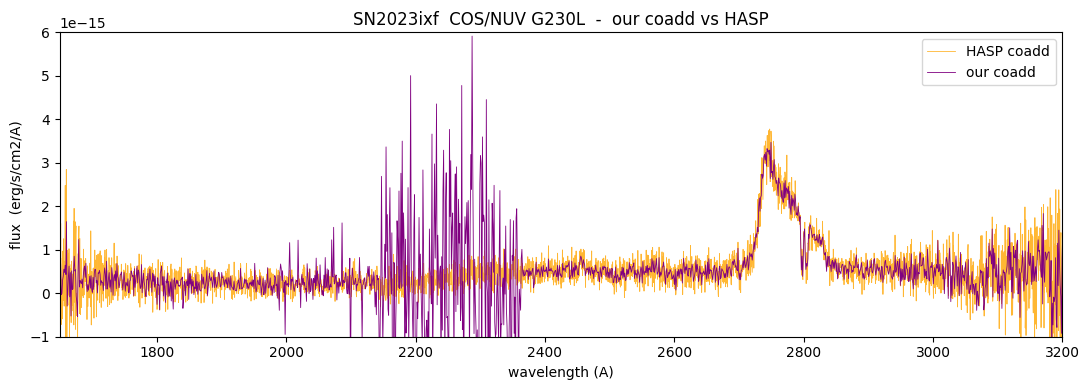

In [10]:
import glob, numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table
from specutils.manipulation import FluxConservingResampler
try:
    from specutils import Spectrum1D
except ImportError:
    from specutils import Spectrum as Spectrum1D

# every stripe of every NUV exposure
sums = sorted(glob.glob(".../data/2023ixf/mastDownload/HST/lf8803[0-9]*/lf8803*_x1dsum.fits"))
allspec, wlo, whi = [], 1e9, 0.0
for fn in sums:
    t = Table.read(fn, hdu=1)
    for i in range(len(t)):
        g = t['DQ_WGT'][i] > 0
        w, f = np.asarray(t['WAVELENGTH'][i][g], float), np.asarray(t['FLUX'][i][g], float)
        if len(w) > 10:
            o = np.argsort(w)
            allspec.append((w[o], f[o]))
            wlo, whi = min(wlo, w.min()), max(whi, w.max())
print(f"{len(sums)} exposures -> {len(allspec)} stripe spectra")

caxis = np.arange(wlo, whi, 1.0) * u.AA
rs = FluxConservingResampler(extrapolation_treatment='nan_fill')
flam = u.erg / u.s / u.cm**2 / u.AA
stack = [rs(Spectrum1D(spectral_axis=w * u.AA, flux=f * flam), caxis).flux.value for w, f in allspec]
ours = np.nanmedian(np.vstack(stack), axis=0)

# HASP coadd to compare
hc = Table.read(glob.glob(".../data/2023ixf/mastDownload/HST/hst_hasp*/*cspec.fits")[0], hdu=1)
hw, hf = hc['WAVELENGTH'][0], hc['FLUX'][0]

plt.figure(figsize=(11, 4))
plt.plot(hw, hf, lw=0.6, color='orange', alpha=0.8, label='HASP coadd')
plt.plot(caxis, ours, lw=0.6, color='purple', label='our coadd')
plt.xlim(1650, 3200); plt.ylim(-1e-15, 6e-15)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)'); plt.legend()
plt.title('SN2023ixf  COS/NUV G230L  -  our coadd vs HASP')
plt.tight_layout(); plt.show()


C:\Users\eluru\AppData\Local\Temp\ipykernel_36260\2147508719.py:31: RuntimeWarning: All-NaN slice encountered
  filtered = np.nanmedian(filtered_stack, axis=0)


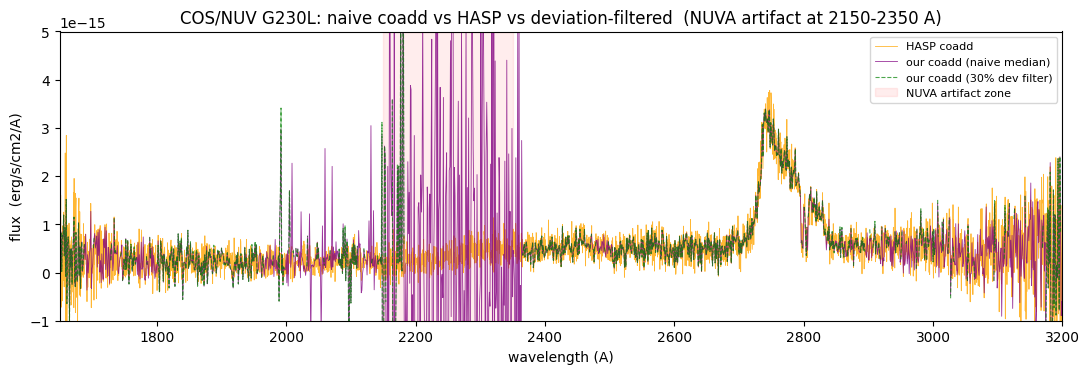

noise outside artifact (2400-3100): ours=6.36e-16  hasp=6.28e-16  ratio=1.012


In [8]:
# our coadd vs HASP: compare noise in each bin and show where they diverge.
# the 2150-2350A discrepancy is the NUVA stripe artifact. HASP drops it via a per-bin flux-deviation
# filter (reject exposures that deviate >~5% from the running median per wavelength bin); our naive
# nanmedian keeps it in. demo of what the filter would look like, and quantify our noise advantage.
import glob, numpy as np, matplotlib.pyplot as plt
from astropy.table import Table

sums = sorted(glob.glob('../data/2023ixf/mastDownload/HST/lf8803[0-9]*/lf8803*_x1dsum.fits'))
all_w, all_f = [], []
for fn in sums:
    t = Table.read(fn, hdu=1)
    for i in range(len(t)):
        g = t['DQ_WGT'][i] > 0
        all_w.append(np.asarray(t['WAVELENGTH'][i][g], float))
        all_f.append(np.asarray(t['FLUX'][i][g], float))
cax = np.arange(1650, 3200, 1.0)
stack = [np.interp(cax, w[np.argsort(w)], f[np.argsort(w)], left=np.nan, right=np.nan) for w, f in zip(all_w, all_f)]
stack = np.vstack(stack)

# hasp coadd
hpath = glob.glob('../data/2023ixf/mastDownload/HST/hst_hasp_17497*/*cspec.fits')[0]
hc = Table.read(hpath, hdu=1)
hw, hf, heff = hc['WAVELENGTH'][0], hc['FLUX'][0], hc['EFF_EXPTIME'][0]
hm = (heff > 0) & np.isfinite(hf) & (hw > 1650) & (hw < 3200)

# naive median = our coadd; deviation-filtered = approximate what HASP does
naive = np.nanmedian(stack, axis=0)
med_stack = np.nanmedian(stack, axis=0, keepdims=True)
devfrac = np.abs(stack - med_stack) / (np.abs(med_stack) + 1e-30)
filtered_stack = np.where(devfrac < 0.30, stack, np.nan)   # 30% threshold demo
filtered = np.nanmedian(filtered_stack, axis=0)

plt.figure(figsize=(11, 4))
plt.plot(hw[hm], hf[hm], lw=0.6, color='orange', alpha=0.8, label='HASP coadd')
plt.plot(cax, naive, lw=0.6, color='purple', alpha=0.8, label='our coadd (naive median)')
plt.plot(cax, filtered, lw=0.8, color='green', alpha=0.7, ls='--', label='our coadd (30% dev filter)')
plt.xlim(1650, 3200); plt.ylim(-1e-15, 5e-15)
plt.axvspan(2150, 2350, color='red', alpha=0.07, label='NUVA artifact zone')
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)'); plt.legend(fontsize=8)
plt.title('COS/NUV G230L: naive coadd vs HASP vs deviation-filtered  (NUVA artifact at 2150-2350 A)')
plt.tight_layout(); plt.show()
# quick noise comparison outside the artifact zone
m = (cax > 2400) & (cax < 3100)
our_noise = np.nanstd(naive[m]); hasp_noise = np.nanstd(np.interp(cax[m], hw[hm], hf[hm], left=np.nan, right=np.nan))
print(f'noise outside artifact (2400-3100): ours={our_noise:.2e}  hasp={hasp_noise:.2e}  ratio={our_noise/hasp_noise:.3f}')